**Instalaciones**

In [ ]:
!pip install roboflow kaggle -q

import os, zipfile, shutil, glob
from PIL import Image
from google.colab import files

print("✓ Librerías instaladas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 37.6 MB/s eta 0:00:00
✓ Librerías instaladas


**Estructura de carpetas**

In [ ]:
WORK_DIR = '/content/tfm'
CLASSES = ['fluido', 'congestion', 'accidente', 'obras']
TARGET_SIZE = (224, 224)

for cls in CLASSES:
    os.makedirs(f'{WORK_DIR}/dataset/{cls}', exist_ok=True)
os.makedirs(f'{WORK_DIR}/raw', exist_ok=True)

print("Carpetas creadas:")
for cls in CLASSES:
    print(f"  {WORK_DIR}/dataset/{cls}")

Carpetas creadas:
  /content/tfm/dataset/fluido
  /content/tfm/dataset/congestion
  /content/tfm/dataset/accidente
  /content/tfm/dataset/obras


**Subir y descomprimir Cityscapes**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

# Ajusta esta ruta a donde esté el zip en ese Drive
ZIP_PATH = '/content/drive/MyDrive/leftImg8bit_trainvaltest.zip'

print("Descomprimiendo desde Drive... (3-5 min)")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(f'{WORK_DIR}/raw/cityscapes')

print("✓ Descomprimido — el zip se queda en Drive, no se borra")

cityscapes_root = f'{WORK_DIR}/raw/cityscapes/leftImg8bit'
for split in ['train', 'val', 'test']:
    split_path = f'{cityscapes_root}/{split}'
    if os.path.exists(split_path):
        print(f"  {split}: {len(os.listdir(split_path))} ciudades")
    else:
        print(f"  {split}: NO ENCONTRADO")

Mounted at /content/drive
Descomprimiendo desde Drive... (3-5 min)
✓ Descomprimido — el zip se queda en Drive, no se borra
  train: 18 ciudades
  val: 3 ciudades
  test: 6 ciudades


**Cityscapes → clase fluido**

In [ ]:
def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

counter = 0
MAX_FLUIDO_CITYSCAPES = 600

for split in ['train', 'val', 'test']:
    split_path = f'{cityscapes_root}/{split}'
    if not os.path.exists(split_path):
        continue
    for city in sorted(os.listdir(split_path)):
        city_path = f'{split_path}/{city}'
        if not os.path.isdir(city_path):
            continue
        for img_file in sorted(os.listdir(city_path)):
            if counter >= MAX_FLUIDO_CITYSCAPES:
                break
            if not img_file.endswith('.png'):
                continue
            src = f'{city_path}/{img_file}'
            if not is_valid_image(src):
                print(f"  Imagen corrupta omitida: {img_file}")
                continue
            dst = f'{WORK_DIR}/dataset/fluido/cityscapes_{counter:05d}.jpg'
            with Image.open(src) as img:
                img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS).save(dst, 'JPEG', quality=90)
            counter += 1
        if counter >= MAX_FLUIDO_CITYSCAPES:
            break

print(f"✓ Cityscapes → fluido: {counter} imágenes")

✓ Cityscapes → fluido: 600 imágenes


**Kaggle: descargar Traffic Density Singapore**

In [ ]:
import json

# Rellena los dos campos:
kaggle_creds = {
    "username": "Yushetf",  # <-- ponlo tú
    "key": "KGAT_e52d98a98e4b09536184b85035faacbd"  # <-- tu token
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json
print("✓ Credenciales configuradas")

print("Descargando Traffic Density Singapore...")
!kaggle datasets download -d rahat52/traffic-density-singapore \
    -p {WORK_DIR}/raw/singapore --unzip

singapore_root = f'{WORK_DIR}/raw/singapore'
print("\nEstructura descargada:")
for root, dirs, fnames in os.walk(singapore_root):
    level = root.replace(singapore_root, '').count(os.sep)
    if level < 3:
        n_imgs = len([f for f in fnames if f.lower().endswith(('.jpg','.jpeg','.png'))])
        indent = '  ' * level
        label = f"  ({n_imgs} imgs)" if n_imgs > 0 else ""
        print(f"{indent}{os.path.basename(root)}/{label}")

✓ Credenciales configuradas
Descargando Traffic Density Singapore...
Dataset URL: https://www.kaggle.com/datasets/rahat52/traffic-density-singapore
License(s): GNU Free Documentation License 1.3
100% 222M/222M [00:01<00:00, 117MB/s]


Estructura descargada:
singapore/
  Final Dataset/
    testing/
    validation/
    training/


**Singapore → fluido y congestion**

In [ ]:
# Mapeo de clases Singapore → tus 4 clases
# Ajusta los nombres exactos según lo que haya impreso la celda anterior
SINGAPORE_MAP = {
    'empty':       'fluido',
    'low':         'fluido',
    'medium':      'fluido',
    'high':        'congestion',
    'traffic Jam': 'congestion',
}

counters_sg = {'fluido': 0, 'congestion': 0}

for root, dirs, fnames in os.walk(singapore_root):
    folder = os.path.basename(root).lower().strip()
    clase = SINGAPORE_MAP.get(folder)
    if clase is None:
        continue
    for fname in fnames:
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        src = os.path.join(root, fname)
        if not is_valid_image(src):
            continue
        n = counters_sg[clase]
        dst = f'{WORK_DIR}/dataset/{clase}/singapore_{n:05d}.jpg'
        with Image.open(src) as img:
            img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS).save(dst, 'JPEG', quality=90)
        counters_sg[clase] += 1

print("✓ Singapore procesado:")
for k, v in counters_sg.items():
    print(f"  {k}: {v} imágenes")

✓ Singapore procesado:
  fluido: 3286 imágenes
  congestion: 480 imágenes


**Roboflow: descargar accidentes y obras**

In [ ]:
from roboflow import Roboflow

API_KEY = "kdf00f3HMaycoX24Td4q"
rf = Roboflow(api_key=API_KEY)

# Dataset accidentes — formato yolov8 (ignoraremos las anotaciones, solo usamos las imágenes)
print("Descargando dataset de accidentes...")
project_crash = rf.workspace("smith-fsuvw").project("car-crash-vjfyg")
dataset_crash = project_crash.version(1).download(
    "yolov8", location=f'{WORK_DIR}/raw/roboflow_accidente')

# Dataset obras — mismo formato
print("\nDescargando dataset de obras...")
project_obras = rf.workspace("bus-hclqm").project("road-construction-ve7zd")
dataset_obras = project_obras.version(1).download(
    "yolov8", location=f'{WORK_DIR}/raw/roboflow_obras')

print("\n✓ Descargas completadas")

Descargando dataset de accidentes...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/tfm/raw/roboflow_accidente in yolov8:: 100%|██████████| 185/185 [00:00<00:00, 4347.38it/s]



Descargando dataset de obras...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/tfm/raw/roboflow_obras in yolov8:: 100%|██████████| 424/424 [00:00<00:00, 7134.23it/s]


✓ Descargas completadas


**Explorar carpetas Roboflow antes de mapear**

In [ ]:
for nombre, ruta in [('ACCIDENTE', f'{WORK_DIR}/raw/roboflow_accidente'),
                     ('OBRAS',     f'{WORK_DIR}/raw/roboflow_obras')]:
    print(f"\n── {nombre} ──")
    for root, dirs, fnames in os.walk(ruta):
        n = len([f for f in fnames if f.lower().endswith(('.jpg','.jpeg','.png'))])
        if n > 0:
            nivel = root.replace(ruta, '')
            print(f"  {nivel}  →  {n} imágenes")


── ACCIDENTE ──
  /valid/images  →  17 imágenes
  /train/images  →  60 imágenes
  /test/images  →  13 imágenes

── OBRAS ──
  /train/images  →  209 imágenes


**Roboflow → accidente y obras**

In [ ]:
counters_rf = {'accidente': 0, 'obras': 0}

# (ruta_raw, clase_destino)
FUENTES = [
    (f'{WORK_DIR}/raw/roboflow_accidente', 'accidente'),
    (f'{WORK_DIR}/raw/roboflow_obras',     'obras'),
]

for ruta_raw, clase in FUENTES:
    for root, dirs, fnames in os.walk(ruta_raw):
        # Solo procesamos carpetas images/, ignoramos labels/
        if not root.endswith('images'):
            continue
        for fname in fnames:
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            src = os.path.join(root, fname)
            if not is_valid_image(src):
                continue
            n = counters_rf[clase]
            dst = f'{WORK_DIR}/dataset/{clase}/roboflow_{n:05d}.jpg'
            with Image.open(src) as img:
                img.convert('RGB').resize(TARGET_SIZE, Image.LANCZOS).save(dst, 'JPEG', quality=90)
            counters_rf[clase] += 1

print("✓ Roboflow procesado:")
for k, v in counters_rf.items():
    print(f"  {k}: {v} imágenes")

✓ Roboflow procesado:
  accidente: 90 imágenes
  obras: 209 imágenes


**Resumen final y diagnóstico**

In [ ]:
print("=" * 40)
print("  RESUMEN DATASET — FIN DÍA 1")
print("=" * 40)

total = 0
minimo = float('inf')
clase_minima = ''

for cls in CLASSES:
    path = f'{WORK_DIR}/dataset/{cls}'
    n = len([f for f in os.listdir(path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total += n
    if n < minimo:
        minimo = n
        clase_minima = cls
    barra = '█' * (n // 30)
    print(f"  {cls:<12} {n:>5}  {barra}")

print("-" * 40)
print(f"  {'TOTAL':<12} {total:>5}")
print()

ratio = max(
    len(os.listdir(f'{WORK_DIR}/dataset/{c}')) for c in CLASSES
) / max(minimo, 1)

if ratio > 5:
    print(f"⚠ Desbalanceo alto (ratio {ratio:.1f}x)")
    print(f"  La clase '{clase_minima}' necesitará augmentation intensivo mañana.")
elif ratio > 2:
    print(f"⚠ Desbalanceo moderado (ratio {ratio:.1f}x)")
    print(f"  Augmentation estándar será suficiente.")
else:
    print(f"✓ Dataset bastante equilibrado (ratio {ratio:.1f}x)")

  RESUMEN DATASET — FIN DÍA 1
  fluido        3886  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  congestion     480  ████████████████
  accidente       90  ███
  obras          209  ██████
----------------------------------------
  TOTAL         4665

⚠ Desbalanceo alto (ratio 43.2x)
  La clase 'accidente' necesitará augmentation intensivo mañana.


**Instalaciones y variables**

In [ ]:
!pip install albumentations -q

import os, shutil, random, numpy as np
from PIL import Image
import albumentations as A
import cv2

WORK_DIR = '/content/tfm'
CLASSES = ['fluido', 'congestion', 'accidente', 'obras']
TARGET_SIZE = (224, 224)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Objetivos por clase tras equilibrado
TARGETS = {
    'fluido':     800,
    'congestion': 600,
    'accidente':  450,
    'obras':      450,
}

print("✓ Listo")

✓ Listo


**Recortar fluido a 800 imágenes**

In [ ]:
fluido_path = f'{WORK_DIR}/dataset/fluido'
todas = [f for f in os.listdir(fluido_path)
         if f.lower().endswith(('.jpg','.jpeg','.png'))]

random.shuffle(todas)
mantener = set(todas[:800])

eliminadas = 0
for f in todas:
    if f not in mantener:
        os.remove(f'{fluido_path}/{f}')
        eliminadas += 1

print(f"✓ fluido: {eliminadas} imágenes eliminadas")
print(f"  Quedan: {len(os.listdir(fluido_path))} imágenes")

✓ fluido: 3086 imágenes eliminadas
  Quedan: 800 imágenes


**Pipeline de augmentation**


In [ ]:
aug_agresivo = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
    A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, p=0.5),
    A.Rotate(limit=15, p=0.5),
    A.GaussNoise(p=0.4),
    A.RandomFog(fog_coef_range=(0.1, 0.3), p=0.3),
    A.RandomRain(slant_range=(-10, 10), p=0.2),
    A.CLAHE(p=0.3),
    A.Resize(224, 224),
])

aug_moderado = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=0.4),
    A.Rotate(limit=10, p=0.4),
    A.GaussNoise(p=0.3),
    A.Resize(224, 224),
])


def augmentar_clase(clase, pipeline, objetivo):
    path = f'{WORK_DIR}/dataset/{clase}'
    originales = [f for f in os.listdir(path)
                  if f.lower().endswith(('.jpg','.jpeg','.png'))]
    n_actual = len(originales)
    necesarias = objetivo - n_actual

    if necesarias <= 0:
        print(f"  {clase}: ya tiene {n_actual} imágenes, no necesita augmentation")
        return

    generadas = 0
    idx = 0
    while generadas < necesarias:
        src = f'{path}/{originales[idx % len(originales)]}'
        img = cv2.imread(src)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        augmented = pipeline(image=img)['image']
        dst = f'{path}/aug_{generadas:05d}.jpg'
        cv2.imwrite(dst, cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR),
                    [cv2.IMWRITE_JPEG_QUALITY, 90])
        generadas += 1
        idx += 1

    print(f"  {clase}: {n_actual} → {n_actual + generadas} imágenes (+{generadas} sintéticas)")

print("✓ Pipelines definidos")

✓ Pipelines definidos


**Aplicar augmentation por clase**

In [ ]:
print("Aplicando augmentation...")
augmentar_clase('accidente',  aug_agresivo,  TARGETS['accidente'])
augmentar_clase('obras',      aug_moderado,  TARGETS['obras'])
augmentar_clase('congestion', aug_moderado,  TARGETS['congestion'])

print("\n✓ Augmentation completado")
print("\nConteo final por clase:")
for cls in CLASSES:
    n = len([f for f in os.listdir(f'{WORK_DIR}/dataset/{cls}')
             if f.lower().endswith(('.jpg','.jpeg','.png'))])
    barra = '█' * (n // 30)
    print(f"  {cls:<12} {n:>5}  {barra}")

Aplicando augmentation...
  accidente: 90 → 450 imágenes (+360 sintéticas)
  obras: 209 → 450 imágenes (+241 sintéticas)
  congestion: 480 → 600 imágenes (+120 sintéticas)

✓ Augmentation completado

Conteo final por clase:
  fluido         800  ██████████████████████████
  congestion     600  ████████████████████
  accidente      450  ███████████████
  obras          450  ███████████████


**Split train/val/test (80/10/10)**

In [ ]:
SPLIT_DIR = f'{WORK_DIR}/dataset_split'

for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        os.makedirs(f'{SPLIT_DIR}/{split}/{cls}', exist_ok=True)

counters_split = {s: {c: 0 for c in CLASSES} for s in ['train','val','test']}

for cls in CLASSES:
    imgs = [f for f in os.listdir(f'{WORK_DIR}/dataset/{cls}')
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(imgs)

    n = len(imgs)
    n_val  = max(1, int(n * 0.10))
    n_test = max(1, int(n * 0.10))
    n_train = n - n_val - n_test

    splits_map = (
        [('train', f) for f in imgs[:n_train]] +
        [('val',   f) for f in imgs[n_train:n_train+n_val]] +
        [('test',  f) for f in imgs[n_train+n_val:]]
    )

    for split, fname in splits_map:
        src = f'{WORK_DIR}/dataset/{cls}/{fname}'
        dst = f'{SPLIT_DIR}/{split}/{cls}/{fname}'
        shutil.copy2(src, dst)
        counters_split[split][cls] += 1

print("✓ Split completado:\n")
print(f"  {'':12} {'train':>6} {'val':>6} {'test':>6}")
print(f"  {'-'*32}")
for cls in CLASSES:
    t = counters_split['train'][cls]
    v = counters_split['val'][cls]
    te = counters_split['test'][cls]
    print(f"  {cls:<12} {t:>6} {v:>6} {te:>6}")

✓ Split completado:

                train    val   test
  --------------------------------
  fluido          640     80     80
  congestion      480     60     60
  accidente       360     45     45
  obras           360     45     45


**Verificación visual (muestra 1 imagen por clase)**

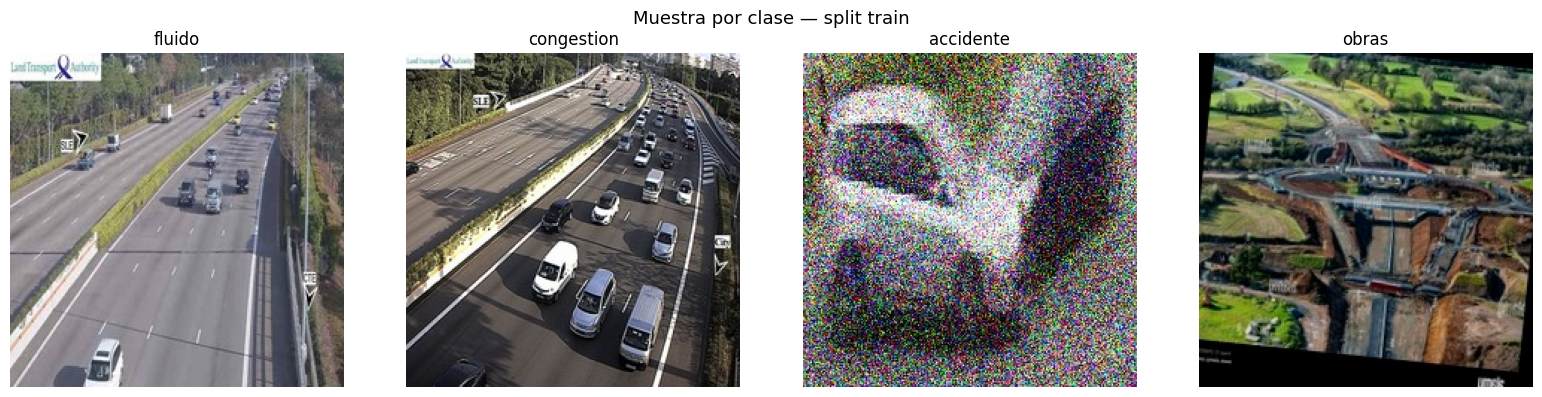

✓ Verificación visual completada


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Muestra por clase — split train', fontsize=13)

for i, cls in enumerate(CLASSES):
    path = f'{SPLIT_DIR}/train/{cls}'
    sample = random.choice(os.listdir(path))
    img = Image.open(f'{path}/{sample}')
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.tight_layout()
plt.show()
print("✓ Verificación visual completada")

**Guardar dataset_split en Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DEST = '/content/drive/MyDrive/TFM/dataset_split'

if os.path.exists(DRIVE_DEST):
    shutil.rmtree(DRIVE_DEST)

print("Guardando dataset_split en Drive... (puede tardar unos minutos)")
shutil.copytree(SPLIT_DIR, DRIVE_DEST)

print("✓ Guardado en Drive")
print("\nVerificación final:")
total = 0
for split in ['train', 'val', 'test']:
    n = sum(
        len(os.listdir(f'{DRIVE_DEST}/{split}/{cls}'))
        for cls in CLASSES
    )
    total += n
    print(f"  {split}: {n} imágenes")
print(f"  TOTAL: {total} imágenes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Guardando dataset_split en Drive... (puede tardar unos minutos)
✓ Guardado en Drive

Verificación final:
  train: 1840 imágenes
  val: 230 imágenes
  test: 230 imágenes
  TOTAL: 2300 imágenes


**Instalaciones y verificación de GPU**

In [ ]:
!pip install torchvision -q

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os, time, copy
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Verificar GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠ No se detecta GPU — revisa que esté activada en Entorno de ejecución")

Dispositivo: cuda
GPU: Tesla T4
Memoria GPU: 15.6 GB


**Cargar dataset_split desde Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil

WORK_DIR = '/content/tfm'
SPLIT_DIR = f'{WORK_DIR}/dataset_split'
CLASSES = ['fluido', 'congestion', 'accidente', 'obras']

# Copiar desde Drive a almacenamiento local (más rápido para entrenar)
DRIVE_SOURCE = '/content/drive/MyDrive/TFM/dataset_split'

if not os.path.exists(SPLIT_DIR):
    print("Copiando dataset desde Drive... (1-2 min)")
    shutil.copytree(DRIVE_SOURCE, SPLIT_DIR)
else:
    print("Dataset ya en local")

# Verificar
print("\nImágenes disponibles:")
for split in ['train', 'val', 'test']:
    n = sum(len(os.listdir(f'{SPLIT_DIR}/{split}/{cls}')) for cls in CLASSES)
    print(f"  {split}: {n} imágenes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset ya en local

Imágenes disponibles:
  train: 1840 imágenes
  val: 230 imágenes
  test: 230 imágenes


**Transforms y DataLoaders**

In [ ]:
SEED = 42
torch.manual_seed(SEED)

# Transforms — normalización ImageNet estándar para transfer learning
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Datasets
image_datasets = {
    'train': datasets.ImageFolder(f'{SPLIT_DIR}/train', train_transforms),
    'val':   datasets.ImageFolder(f'{SPLIT_DIR}/val',   val_test_transforms),
    'test':  datasets.ImageFolder(f'{SPLIT_DIR}/test',  val_test_transforms),
}

# DataLoaders
dataloaders = {
    split: DataLoader(image_datasets[split],
                      batch_size=32,
                      shuffle=(split == 'train'),
                      num_workers=2)
    for split in ['train', 'val', 'test']
}

class_names = image_datasets['train'].classes
print(f"Clases detectadas: {class_names}")
print(f"Orden de clases: {image_datasets['train'].class_to_idx}")
print(f"\nTamaño de batches:")
for split in ['train', 'val', 'test']:
    print(f"  {split}: {len(dataloaders[split])} batches de 32")

Clases detectadas: ['accidente', 'congestion', 'fluido', 'obras']
Orden de clases: {'accidente': 0, 'congestion': 1, 'fluido': 2, 'obras': 3}

Tamaño de batches:
  train: 58 batches de 32
  val: 8 batches de 32
  test: 8 batches de 32


**Función de entrenamiento**

In [ ]:
def train_model(model, model_name, criterion, optimizer, scheduler, num_epochs=15):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'val_loss': [],
                'train_acc': [],  'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}', end=' — ')

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc  = running_corrects.double() / len(image_datasets[phase])

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} loss={epoch_loss:.4f} acc={epoch_acc:.4f}', end='  ')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    elapsed = time.time() - since
    print(f'\n✓ {model_name} entrenado en {elapsed//60:.0f}m {elapsed%60:.0f}s')
    print(f'  Mejor val accuracy: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

print("✓ Función de entrenamiento definida")

✓ Función de entrenamiento definida


**Entrenar ResNet50**

In [ ]:
# Cargar ResNet50 preentrenado en ImageNet
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Congelar todas las capas excepto la última
for param in resnet.parameters():
    param.requires_grad = False

# Reemplazar la capa final para 4 clases
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 4)
resnet = resnet.to(device)

# Solo entrenamos la capa final
optimizer_res = optim.Adam(resnet.fc.parameters(), lr=1e-3)
scheduler_res = optim.lr_scheduler.StepLR(optimizer_res, step_size=7, gamma=0.1)
criterion = nn.CrossEntropyLoss()

print("Entrenando ResNet50...")
resnet, history_res = train_model(
    resnet, 'ResNet50', criterion,
    optimizer_res, scheduler_res, num_epochs=15
)

# Guardar modelo
torch.save(resnet.state_dict(), '/content/drive/MyDrive/TFM/resnet50_tfm.pth')
print("✓ ResNet50 guardado en Drive")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 75.8MB/s]


Entrenando ResNet50...
Epoch 1/15 — train loss=0.8806 acc=0.6576  val loss=0.5397 acc=0.8043  
Epoch 2/15 — train loss=0.4627 acc=0.8582  val loss=0.3523 acc=0.8870  
Epoch 3/15 — train loss=0.3893 acc=0.8734  val loss=0.3233 acc=0.9000  
Epoch 4/15 — train loss=0.3449 acc=0.8859  val loss=0.2907 acc=0.9043  
Epoch 5/15 — train loss=0.3356 acc=0.8826  val loss=0.2618 acc=0.9087  
Epoch 6/15 — train loss=0.2988 acc=0.8880  val loss=0.3356 acc=0.8696  
Epoch 7/15 — train loss=0.2797 acc=0.8978  val loss=0.2417 acc=0.9087  
Epoch 8/15 — train loss=0.2544 acc=0.9125  val loss=0.2336 acc=0.9174  
Epoch 9/15 — train loss=0.2416 acc=0.9163  val loss=0.2344 acc=0.9174  
Epoch 10/15 — train loss=0.2391 acc=0.9174  val loss=0.2335 acc=0.9217  
Epoch 11/15 — train loss=0.2397 acc=0.9212  val loss=0.2321 acc=0.9217  
Epoch 12/15 — train loss=0.2442 acc=0.9174  val loss=0.2322 acc=0.9087  
Epoch 13/15 — train loss=0.2315 acc=0.9228  val loss=0.2303 acc=0.9217  
Epoch 14/15 — train loss=0.2292 acc=0

**Entrenar EfficientNetB0**

In [ ]:
# Cargar EfficientNetB0 preentrenado
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Congelar todas las capas
for param in efficientnet.parameters():
    param.requires_grad = False

# Reemplazar clasificador final para 4 clases
num_features = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(num_features, 4)
efficientnet = efficientnet.to(device)

optimizer_eff = optim.Adam(efficientnet.classifier.parameters(), lr=1e-3)
scheduler_eff = optim.lr_scheduler.StepLR(optimizer_eff, step_size=7, gamma=0.1)

print("Entrenando EfficientNetB0...")
efficientnet, history_eff = train_model(
    efficientnet, 'EfficientNetB0', criterion,
    optimizer_eff, scheduler_eff, num_epochs=15
)

torch.save(efficientnet.state_dict(), '/content/drive/MyDrive/TFM/efficientnet_b0_tfm.pth')
print("✓ EfficientNetB0 guardado en Drive")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 154MB/s]


Entrenando EfficientNetB0...
Epoch 1/15 — train loss=0.8505 acc=0.6891  val loss=0.5384 acc=0.8478  
Epoch 2/15 — train loss=0.5084 acc=0.8408  val loss=0.4510 acc=0.8217  
Epoch 3/15 — train loss=0.4169 acc=0.8690  val loss=0.3831 acc=0.8696  
Epoch 4/15 — train loss=0.3850 acc=0.8788  val loss=0.3633 acc=0.8652  
Epoch 5/15 — train loss=0.3424 acc=0.8902  val loss=0.3244 acc=0.8826  
Epoch 6/15 — train loss=0.3092 acc=0.8929  val loss=0.3149 acc=0.8696  
Epoch 7/15 — train loss=0.2970 acc=0.9043  val loss=0.2949 acc=0.8913  
Epoch 8/15 — train loss=0.2837 acc=0.9016  val loss=0.2849 acc=0.9130  
Epoch 9/15 — train loss=0.2874 acc=0.8995  val loss=0.3027 acc=0.8870  
Epoch 10/15 — train loss=0.2873 acc=0.9109  val loss=0.2875 acc=0.9000  
Epoch 11/15 — train loss=0.2685 acc=0.9130  val loss=0.2909 acc=0.8870  
Epoch 12/15 — train loss=0.2814 acc=0.9054  val loss=0.2785 acc=0.9087  
Epoch 13/15 — train loss=0.2764 acc=0.9092  val loss=0.2994 acc=0.8826  
Epoch 14/15 — train loss=0.2748

**Curvas de aprendizaje**

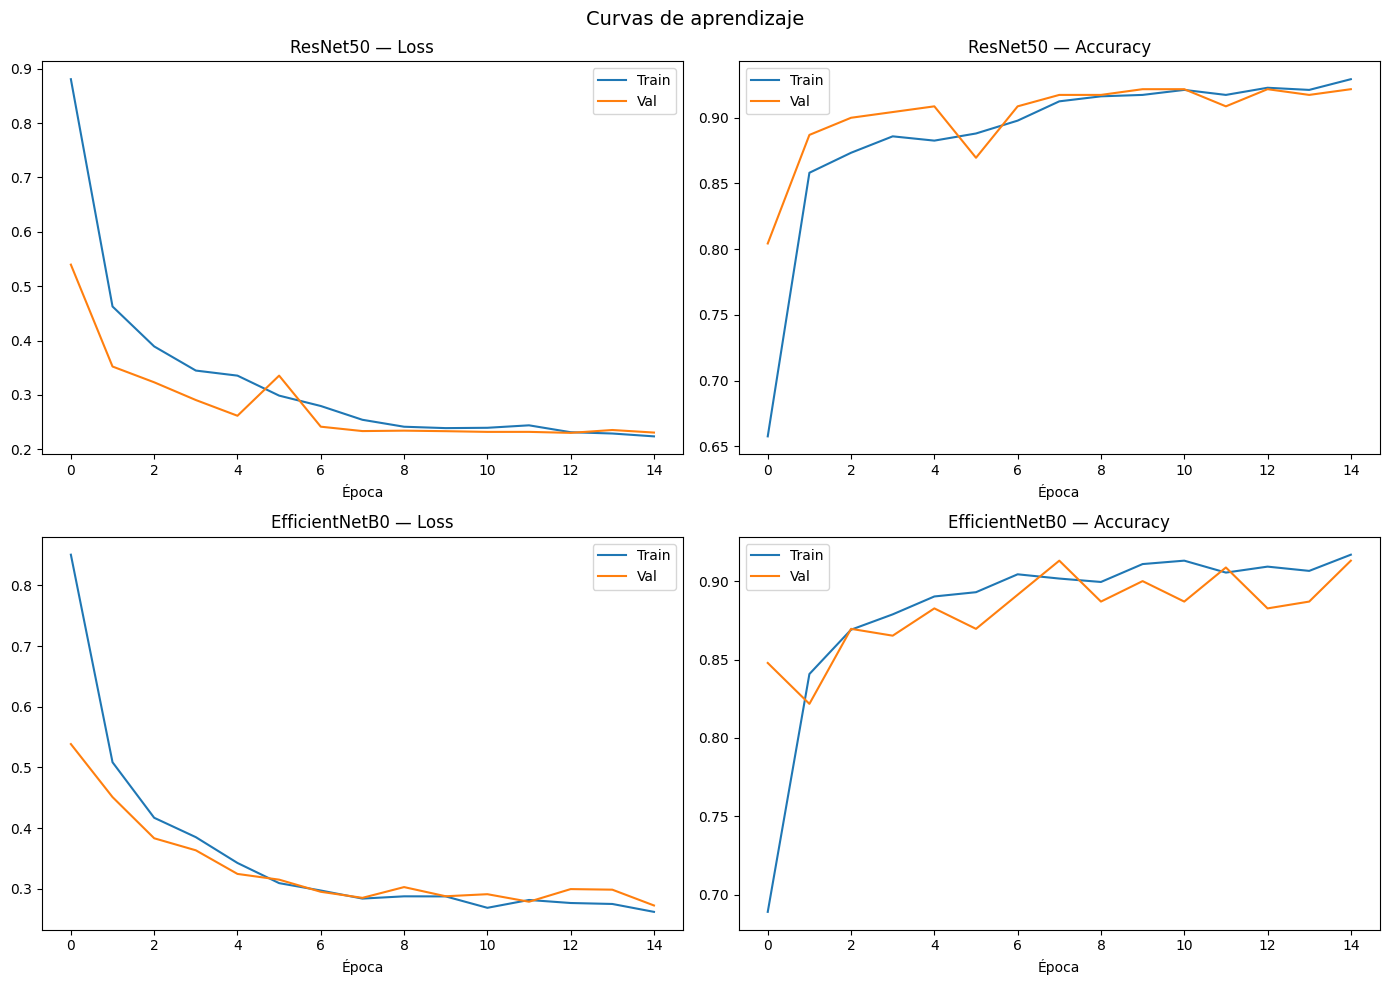

✓ Curvas guardadas en Drive


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Curvas de aprendizaje', fontsize=14)

for i, (history, name) in enumerate([(history_res, 'ResNet50'),
                                       (history_eff, 'EfficientNetB0')]):
    # Loss
    axes[i][0].plot(history['train_loss'], label='Train')
    axes[i][0].plot(history['val_loss'],   label='Val')
    axes[i][0].set_title(f'{name} — Loss')
    axes[i][0].set_xlabel('Época')
    axes[i][0].legend()

    # Accuracy
    axes[i][1].plot(history['train_acc'], label='Train')
    axes[i][1].plot(history['val_acc'],   label='Val')
    axes[i][1].set_title(f'{name} — Accuracy')
    axes[i][1].set_xlabel('Época')
    axes[i][1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFM/curvas_aprendizaje.png', dpi=150)
plt.show()
print("✓ Curvas guardadas en Drive")

**Evaluación en test y matrices de confusión**


  ResNet50 — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.89      0.93      0.91        45
  congestion       0.85      0.85      0.85        60
      fluido       0.90      0.91      0.91        80
       obras       0.95      0.89      0.92        45

    accuracy                           0.90       230
   macro avg       0.90      0.90      0.90       230
weighted avg       0.90      0.90      0.90       230



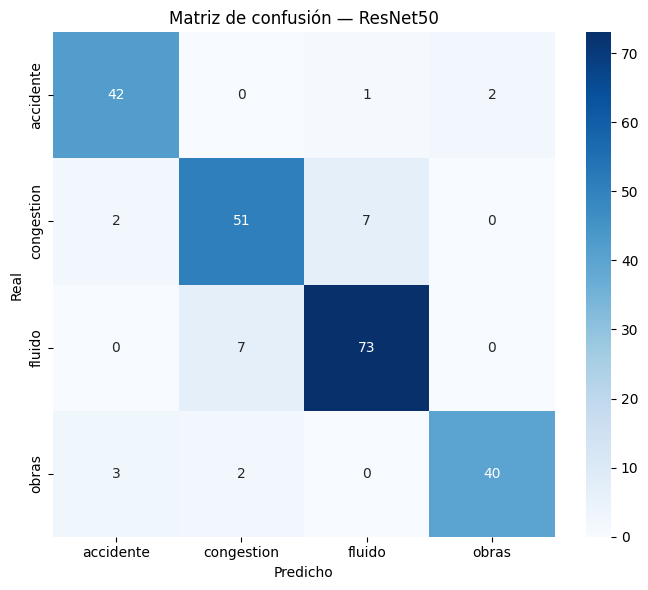


  EfficientNetB0 — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.90      0.96      0.92        45
  congestion       0.94      0.85      0.89        60
      fluido       0.91      0.96      0.93        80
       obras       0.98      0.93      0.95        45

    accuracy                           0.93       230
   macro avg       0.93      0.93      0.93       230
weighted avg       0.93      0.93      0.93       230



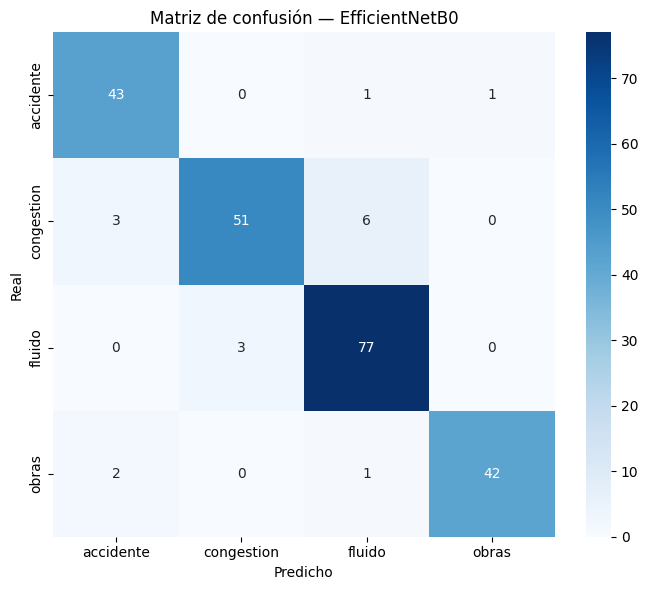

In [ ]:
def evaluar_modelo(model, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    print(f"\n{'='*45}")
    print(f"  {model_name} — Resultados en TEST")
    print(f"{'='*45}")
    print(classification_report(all_labels, all_preds,
                                 target_names=class_names))

    # Matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de confusión — {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Predicho')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/TFM/confusion_{model_name}.png', dpi=150)
    plt.show()

evaluar_modelo(resnet, 'ResNet50')
evaluar_modelo(efficientnet, 'EfficientNetB0')

**Baseline: CNN desde cero**

In [ ]:
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 112x112

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 56x56

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 28x28

            # Bloque 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 14x14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

baseline = BaselineCNN(num_classes=4).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in baseline.parameters())
print(f"Parámetros baseline CNN: {total_params:,}")

optimizer_base = optim.Adam(baseline.parameters(), lr=1e-3)
scheduler_base = optim.lr_scheduler.StepLR(optimizer_base, step_size=7, gamma=0.1)

print("\nEntrenando Baseline CNN...")
baseline, history_base = train_model(
    baseline, 'BaselineCNN', criterion,
    optimizer_base, scheduler_base, num_epochs=15
)

torch.save(baseline.state_dict(), '/content/drive/MyDrive/TFM/baseline_cnn.pth')
print("✓ Baseline guardado en Drive")

Parámetros baseline CNN: 2,489,092

Entrenando Baseline CNN...
Epoch 1/15 — train loss=1.3566 acc=0.4772  val loss=1.1594 acc=0.5870  
Epoch 2/15 — train loss=0.7155 acc=0.7022  val loss=0.5804 acc=0.7522  
Epoch 3/15 — train loss=0.6177 acc=0.7495  val loss=0.6220 acc=0.7609  
Epoch 4/15 — train loss=0.5601 acc=0.7603  val loss=0.4963 acc=0.7957  
Epoch 5/15 — train loss=0.5118 acc=0.7946  val loss=0.4668 acc=0.8304  
Epoch 6/15 — train loss=0.4390 acc=0.8364  val loss=0.4671 acc=0.8304  
Epoch 7/15 — train loss=0.4434 acc=0.8342  val loss=0.4173 acc=0.8565  
Epoch 8/15 — train loss=0.3223 acc=0.8734  val loss=0.3436 acc=0.8522  
Epoch 9/15 — train loss=0.3079 acc=0.8848  val loss=0.3176 acc=0.8739  
Epoch 10/15 — train loss=0.2871 acc=0.8935  val loss=0.3146 acc=0.8783  
Epoch 11/15 — train loss=0.2733 acc=0.9005  val loss=0.3106 acc=0.8870  
Epoch 12/15 — train loss=0.2703 acc=0.9054  val loss=0.3068 acc=0.8957  
Epoch 13/15 — train loss=0.2633 acc=0.9049  val loss=0.3024 acc=0.8870

**Fine-tuning ResNet50**

In [ ]:
# Recargar ResNet50 con los pesos del día 3
resnet_ft = models.resnet50(weights=None)
resnet_ft.fc = nn.Linear(resnet_ft.fc.in_features, 4)
resnet_ft.load_state_dict(torch.load('/content/drive/MyDrive/TFM/resnet50_tfm.pth'))
resnet_ft = resnet_ft.to(device)

# Descongelar layer3, layer4 y fc
for name, param in resnet_ft.named_parameters():
    if any(layer in name for layer in ['layer3', 'layer4', 'fc']):
        param.requires_grad = True
    else:
        param.requires_grad = False

# Contar parámetros entrenables
trainable = sum(p.numel() for p in resnet_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet_ft.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Learning rate bajo para fine-tuning
optimizer_ft = optim.Adam([
    {'params': resnet_ft.layer3.parameters(), 'lr': 1e-5},
    {'params': resnet_ft.layer4.parameters(), 'lr': 1e-4},
    {'params': resnet_ft.fc.parameters(),     'lr': 1e-3},
])
scheduler_ft = optim.lr_scheduler.StepLR(optimizer_ft, step_size=5, gamma=0.1)

print("\nEntrenando ResNet50 fine-tuning...")
resnet_ft, history_ft = train_model(
    resnet_ft, 'ResNet50_FineTuning', criterion,
    optimizer_ft, scheduler_ft, num_epochs=15
)

torch.save(resnet_ft.state_dict(), '/content/drive/MyDrive/TFM/resnet50_finetuned.pth')
print("✓ ResNet50 fine-tuned guardado en Drive")

Parámetros entrenables: 22,071,300 / 23,516,228 (93.9%)

Entrenando ResNet50 fine-tuning...
Epoch 1/15 — train loss=0.2778 acc=0.9005  val loss=0.1927 acc=0.9304  
Epoch 2/15 — train loss=0.1033 acc=0.9620  val loss=0.2036 acc=0.9391  
Epoch 3/15 — train loss=0.0783 acc=0.9734  val loss=0.1527 acc=0.9609  
Epoch 4/15 — train loss=0.0446 acc=0.9859  val loss=0.0913 acc=0.9739  
Epoch 5/15 — train loss=0.0471 acc=0.9864  val loss=0.1383 acc=0.9609  
Epoch 6/15 — train loss=0.0206 acc=0.9946  val loss=0.1265 acc=0.9696  
Epoch 7/15 — train loss=0.0119 acc=0.9973  val loss=0.1255 acc=0.9739  
Epoch 8/15 — train loss=0.0138 acc=0.9946  val loss=0.1114 acc=0.9783  
Epoch 9/15 — train loss=0.0082 acc=0.9984  val loss=0.1167 acc=0.9783  
Epoch 10/15 — train loss=0.0058 acc=1.0000  val loss=0.1114 acc=0.9783  
Epoch 11/15 — train loss=0.0053 acc=0.9995  val loss=0.1110 acc=0.9783  
Epoch 12/15 — train loss=0.0057 acc=0.9989  val loss=0.1097 acc=0.9783  
Epoch 13/15 — train loss=0.0043 acc=0.999

**Fine-tuning EfficientNetB0**

In [ ]:
# Fine-tuning EfficientNetB0
efficientnet_ft = models.efficientnet_b0(weights=None)
efficientnet_ft.classifier[1] = nn.Linear(efficientnet_ft.classifier[1].in_features, 4)
efficientnet_ft.load_state_dict(torch.load('/content/drive/MyDrive/TFM/efficientnet_b0_tfm.pth'))
efficientnet_ft = efficientnet_ft.to(device)

# Descongelar los últimos bloques
for name, param in efficientnet_ft.named_parameters():
    if any(block in name for block in ['features.6', 'features.7', 'features.8', 'classifier']):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in efficientnet_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in efficientnet_ft.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

optimizer_eff_ft = optim.Adam([
    {'params': efficientnet_ft.features[6].parameters(), 'lr': 1e-5},
    {'params': efficientnet_ft.features[7].parameters(), 'lr': 1e-5},
    {'params': efficientnet_ft.features[8].parameters(), 'lr': 1e-4},
    {'params': efficientnet_ft.classifier.parameters(),  'lr': 1e-3},
])
scheduler_eff_ft = optim.lr_scheduler.StepLR(optimizer_eff_ft, step_size=5, gamma=0.1)

print("\nEntrenando EfficientNetB0 fine-tuning...")
efficientnet_ft, history_eff_ft = train_model(
    efficientnet_ft, 'EfficientNetB0_FineTuning', criterion,
    optimizer_eff_ft, scheduler_eff_ft, num_epochs=15
)

torch.save(efficientnet_ft.state_dict(), '/content/drive/MyDrive/TFM/efficientnet_b0_finetuned.pth')
print("✓ EfficientNetB0 fine-tuned guardado en Drive")

Parámetros entrenables: 3,160,864 / 4,012,672 (78.8%)

Entrenando EfficientNetB0 fine-tuning...
Epoch 1/15 — train loss=0.2719 acc=0.9114  val loss=0.2423 acc=0.9130  
Epoch 2/15 — train loss=0.2362 acc=0.9163  val loss=0.2166 acc=0.9348  
Epoch 3/15 — train loss=0.1882 acc=0.9304  val loss=0.2107 acc=0.9130  
Epoch 4/15 — train loss=0.1716 acc=0.9380  val loss=0.2020 acc=0.9261  
Epoch 5/15 — train loss=0.1465 acc=0.9484  val loss=0.1984 acc=0.8957  
Epoch 6/15 — train loss=0.1382 acc=0.9484  val loss=0.1961 acc=0.9174  
Epoch 7/15 — train loss=0.1287 acc=0.9598  val loss=0.1942 acc=0.9087  
Epoch 8/15 — train loss=0.1274 acc=0.9543  val loss=0.1949 acc=0.9174  
Epoch 9/15 — train loss=0.1392 acc=0.9516  val loss=0.1879 acc=0.9217  
Epoch 10/15 — train loss=0.1283 acc=0.9538  val loss=0.1902 acc=0.9174  
Epoch 11/15 — train loss=0.1146 acc=0.9576  val loss=0.1882 acc=0.9130  
Epoch 12/15 — train loss=0.1215 acc=0.9598  val loss=0.1904 acc=0.9348  
Epoch 13/15 — train loss=0.1192 acc=0

**Evaluación baseline y fine-tuning**


  BaselineCNN — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.93      0.96      0.95        45
  congestion       0.91      0.83      0.87        60
      fluido       0.90      0.95      0.93        80
       obras       0.96      0.96      0.96        45

    accuracy                           0.92       230
   macro avg       0.93      0.92      0.92       230
weighted avg       0.92      0.92      0.92       230



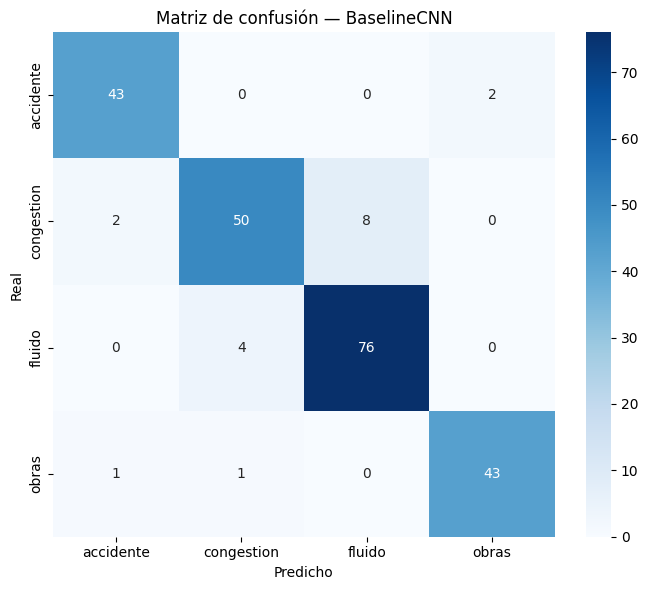


  ResNet50_FineTuning — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.98      0.98      0.98        45
  congestion       0.92      0.93      0.93        60
      fluido       0.96      0.96      0.96        80
       obras       0.98      0.96      0.97        45

    accuracy                           0.96       230
   macro avg       0.96      0.96      0.96       230
weighted avg       0.96      0.96      0.96       230



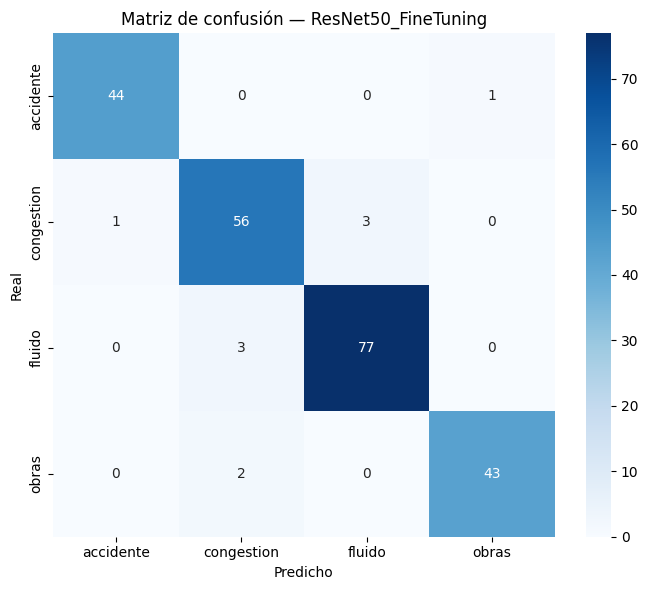


  EfficientNetB0_FineTuning — Resultados en TEST
              precision    recall  f1-score   support

   accidente       0.91      0.91      0.91        45
  congestion       0.94      0.85      0.89        60
      fluido       0.91      0.96      0.93        80
       obras       0.93      0.96      0.95        45

    accuracy                           0.92       230
   macro avg       0.92      0.92      0.92       230
weighted avg       0.92      0.92      0.92       230



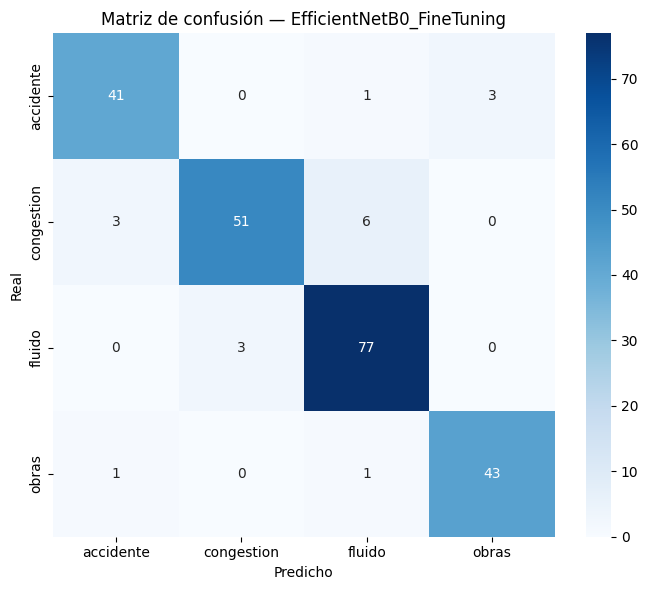

In [ ]:
evaluar_modelo(baseline, 'BaselineCNN')
evaluar_modelo(resnet_ft, 'ResNet50_FineTuning')
evaluar_modelo(efficientnet_ft, 'EfficientNetB0_FineTuning')

**Tabla comparativa**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def get_metrics(model):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro')
    return acc, f1

print("=" * 55)
print(f"  {'Modelo':<25} {'Accuracy':>10} {'Macro F1':>10}")
print("=" * 55)

modelos = [
    (baseline,        'Baseline CNN'),
    (resnet,          'ResNet50 (Transfer)'),
    (resnet_ft,       'ResNet50 (Fine-tuning)'),
    (efficientnet,    'EfficientNetB0 (Transfer)'),
    (efficientnet_ft, 'EfficientNetB0 (Fine-tuning)'),
]

for model, name in modelos:
    acc, f1 = get_metrics(model)
    print(f"  {name:<25} {acc:>10.4f} {f1:>10.4f}")

print("=" * 55)

  Modelo                      Accuracy   Macro F1
  Baseline CNN                  0.9217     0.9243
  ResNet50 (Transfer)           0.8957     0.8974
  ResNet50 (Fine-tuning)        0.9565     0.9580
  EfficientNetB0 (Transfer)     0.9261     0.9268
  EfficientNetB0 (Fine-tuning)     0.9217     0.9211


**Curvas comparativas**

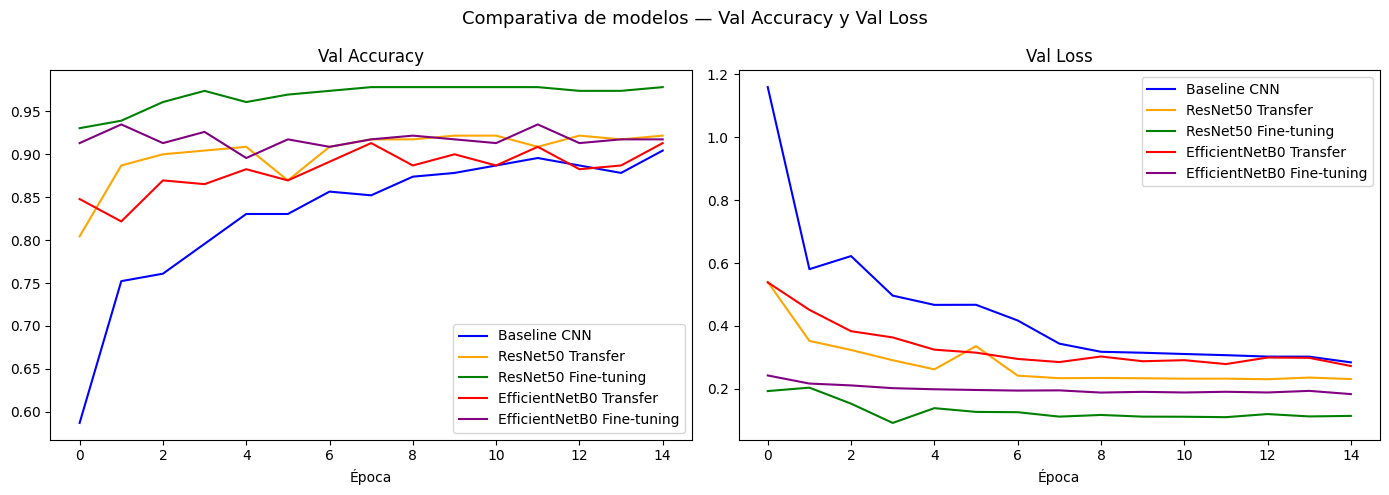

✓ Comparativa guardada en Drive


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparativa de modelos — Val Accuracy y Val Loss', fontsize=13)

configs = [
    (history_base,    'Baseline CNN',                  'blue'),
    (history_res,     'ResNet50 Transfer',              'orange'),
    (history_ft,      'ResNet50 Fine-tuning',           'green'),
    (history_eff,     'EfficientNetB0 Transfer',                 'red'),
    (history_eff_ft,  'EfficientNetB0 Fine-tuning',     'purple'),
]

for history, name, color in configs:
    axes[0].plot(history['val_acc'],  label=name, color=color)
    axes[1].plot(history['val_loss'], label=name, color=color)

axes[0].set_title('Val Accuracy')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].set_title('Val Loss')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/TFM/comparativa_modelos.png', dpi=150)
plt.show()
print("✓ Comparativa guardada en Drive")